In [1]:
import cv2
import matplotlib.pyplot as plt
import glob
cv_img = []

In [2]:
for i in range(1,17):
  for img in glob.glob(f"output/crop{i}.png"):
    n= cv2.imread(img)
    cv_img.append(n)

In [3]:
z_cordinate=[]
x_cordinate=[]
for i in range(0,len(cv_img)):
  h,w,_=cv_img[i].shape
  z=[]
  x=[]
  for l in range(0,h):
    for j in range(0,w):
      b,g,r=cv_img[i][l,j]
      if (b,g,r)!=(0,0,0):
        z.append(j)
        x.append(l)
  #z.append(h)
  #x.append(w)
  z_cordinate.append(z)
  x_cordinate.append(x)

In [4]:
s=1.5
y_axis=[]
for i in range(1,12):
  y_axis.append(s)
  s=s+1.5
print(y_axis)

[1.5, 3.0, 4.5, 6.0, 7.5, 9.0, 10.5, 12.0, 13.5, 15.0, 16.5]


In [5]:
# importing mplot3d toolkits
from mpl_toolkits import mplot3d
import numpy as np
import matplotlib.pyplot as plt

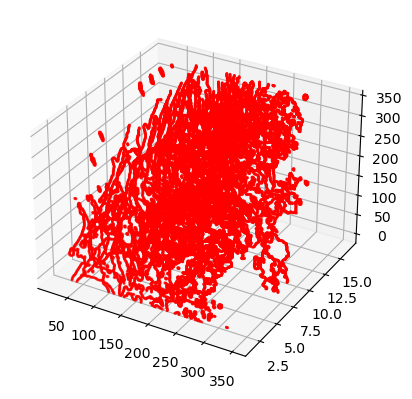

In [6]:
fig = plt.figure()

# syntax for 3-D projection
ax = plt.axes(projection ='3d')

# defining axes
test=[]
for i in range(0,len(y_axis)):

  ax.scatter(x_cordinate[i], y_axis[i], z_cordinate[i], color='red',s=1)
  for k in range(len(x_cordinate[i])):
    test.append([x_cordinate[i][k],z_cordinate[i][k],y_axis[i]])

In [7]:
# syntax for plotting
ax.set_title('3d Scatter conical flask')
ax.set_xlabel('X Label')
ax.set_ylabel('Y Label')
ax.set_zlabel('Z Label')
ax.view_init(30, -60)
plt.show()

In [8]:
'''cor=[]
for i in range(len(y_axis)):
  for k in range(len(x_cordinate[i])):
    sub=[]
    sub.append(x_cordinate[i][k])
    sub.append(y_axis[i])
    sub.append(x_cordinate[i][k])
    cor.append(sub)'''

'cor=[]\nfor i in range(len(y_axis)):\n  for k in range(len(x_cordinate[i])):\n    sub=[]\n    sub.append(x_cordinate[i][k])\n    sub.append(y_axis[i])\n    sub.append(x_cordinate[i][k])\n    cor.append(sub)'

In [9]:
import open3d as o3d
#xyz = np.random.rand(100, 3)
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(test)
o3d.io.write_point_cloud('data2.ply', pcd)
o3d.visualization.draw_geometries([pcd])

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The requested transformation operation is not supported. 
[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The handle is invalid. 
[Open3D WARNING] [ViewControl] SetViewPoint() failed because window height and width are not set.


In [10]:
import numpy as np
import pyvista as pv

C:\Users\Nikitha R\anaconda3\lib\site-packages\pyvista\jupyter\notebook.py:58: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


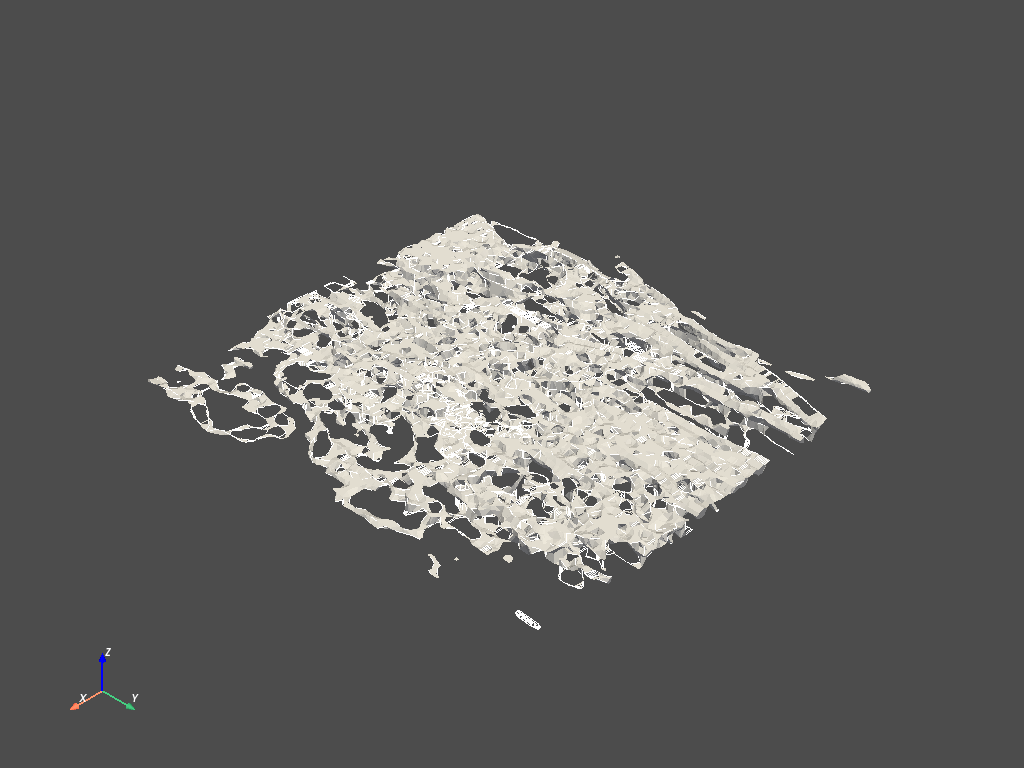

In [11]:
# points is a 3D numpy array (n_points, 3) coordinates of a sphere
cloud = pv.PolyData(test)
#cloud.plot()

volume = cloud.delaunay_3d(alpha=3.)
shell = volume.extract_geometry()
shell.plot()